# Solving a simplified System

Solving deposition PDE: 100%|██████████| 500/500 [00:11<00:00, 42.60it/s]


✅ Solver finished. Final lumps deposit = 0.21090355694444768


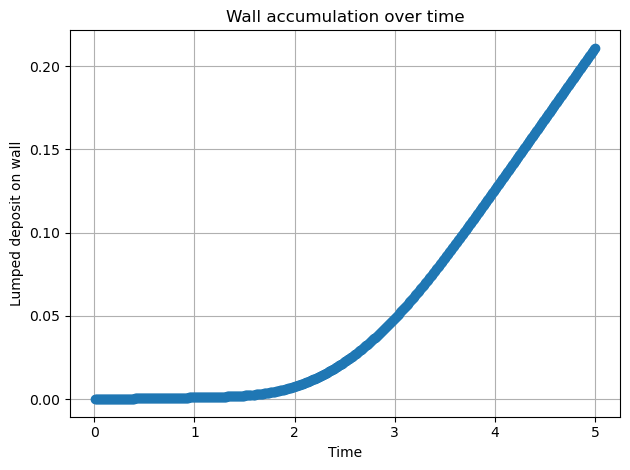

In [ ]:
import netgen.meshing as meshing
from netgen.geom2d import SplineGeometry
from ngsolve import *
from ngsolve.solvers import GMRes
from ngsolve.la import BaseMatrix
from ngsolve.webgui import Draw
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # ✅ Progress bar

class IdentityPreconditioner(BaseMatrix):
    def __init__(self, size):
        super().__init__()
        self._size = size
    def Height(self): return self._size
    def Width(self): return self._size
    def Mult(self, x, y): y.data = x

def SolveKineticDeposition_WithRemoval(
    mesh,
    velocity_cf,
    E_cf,
    D=1e-3,
    mu_e=1e-1,
    dt=0.01,
    T=2.0,
    c0_value=0.5,
    inflow_c=1.0,
    kd=1.0
):
    fes_c = H1(mesh, order=1, dirichlet="inflow")
    c_gf = GridFunction(fes_c, "c")
    c_gf.Set(c0_value)
    c_gf.Set(inflow_c, definedon=mesh.Boundaries("inflow"))

    u = fes_c.TrialFunction()
    v = fes_c.TestFunction()

    mass = BilinearForm(fes_c, symmetric=True)
    mass += u * v * dx
    mass.Assemble()

    drift_cf = velocity_cf + mu_e * E_cf

    a = BilinearForm(fes_c, symmetric=False)
    a += D * grad(u) * grad(v) * dx
    a += (drift_cf * grad(u)) * v * dx
    a += kd * u * v * ds("wall")
    a.Assemble()

    mat = mass.mat.CreateMatrix()
    mat.AsVector().data = mass.mat.AsVector() + dt * a.mat.AsVector()

    pre = IdentityPreconditioner(mat.height)

    old_sol = c_gf.vec.CreateVector()
    old_sol.data = c_gf.vec
    rhs_vec = c_gf.vec.CreateVector()

    c_timeline = GridFunction(fes_c, multidim=0)
    c_timeline.AddMultiDimComponent(c_gf.vec)

    times = []
    deposit_history = []
    lumps_deposit = 0.0

    nsteps = int(T / dt)

    for step in tqdm(range(nsteps), desc="Solving deposition PDE"):
        tcur = (step + 1) * dt
        rhs_vec.data = mass.mat * old_sol
        c_gf.vec.data = 0.0 * c_gf.vec

        GMRes(A=mat, b=rhs_vec, x=c_gf.vec, pre=pre,
              maxsteps=1000, tol=1e-8, restart=1000, printrates=False)

        if step % 100 == 0:
            c_timeline.AddMultiDimComponent(c_gf.vec)

        old_sol.data = c_gf.vec

        c_wall = Integrate(c_gf, mesh, BND, definedon=mesh.Boundaries("wall"))
        lumps_deposit += dt * kd * c_wall
        times.append(tcur)
        deposit_history.append(lumps_deposit)

    return c_timeline, times, deposit_history

if __name__ == "__main__":
    geo = SplineGeometry()
    geo.AddRectangle((0, 0), (3, 1), bcs=["inflow", "wall", "outflow", "wall"])
    mesh = Mesh(geo.GenerateMesh(maxh=0.02))

    from ngsolve import x, y, IfPos
    velocity_cf = CoefficientFunction((5 * y * (1 - y), 0))
    E_switch = IfPos(x - 0.5, IfPos(2.5 - x, 1.0, 0.0), 0.0)
    E_cf = CoefficientFunction((0, E_switch))

    c_hist, times, deposit_hist = SolveKineticDeposition_WithRemoval(
        mesh=mesh,
        velocity_cf=velocity_cf,
        E_cf=E_cf,
        D=1e-3,
        mu_e=0.1,
        dt=0.01,
        T=5.0,
        c0_value=0.5,
        inflow_c=1.0,
        kd=2.0
    )

    print("✅ Solver finished. Final lumps deposit =", deposit_hist[-1])

    plt.figure()
    plt.plot(times, deposit_hist, marker='o', linestyle='--')
    plt.xlabel("Time")
    plt.ylabel("Lumped deposit on wall")
    plt.title("Wall accumulation over time")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("Scurve_physical.png")
    plt.show()
    Draw(c_hist, mesh, "c_timeline")

Step 1/500, time=0.01, c_wall=2.5252e-04, deposit=5.0504e-06
Step 2/500, time=0.02, c_wall=1.4617e-04, deposit=7.9738e-06
Step 3/500, time=0.03, c_wall=1.2308e-04, deposit=1.0435e-05
Step 4/500, time=0.04, c_wall=1.1609e-04, deposit=1.2757e-05
Step 5/500, time=0.05, c_wall=1.1452e-04, deposit=1.5048e-05
Step 6/500, time=0.06, c_wall=1.1589e-04, deposit=1.7365e-05
Step 7/500, time=0.07, c_wall=1.1861e-04, deposit=1.9737e-05
Step 8/500, time=0.08, c_wall=1.2180e-04, deposit=2.2173e-05
Step 9/500, time=0.09, c_wall=1.2523e-04, deposit=2.4678e-05
Step 10/500, time=0.10, c_wall=1.2867e-04, deposit=2.7251e-05
Step 11/500, time=0.11, c_wall=1.3217e-04, deposit=2.9895e-05
Step 12/500, time=0.12, c_wall=1.3560e-04, deposit=3.2607e-05
Step 13/500, time=0.13, c_wall=1.3896e-04, deposit=3.5386e-05
Step 14/500, time=0.14, c_wall=1.4220e-04, deposit=3.8230e-05
Step 15/500, time=0.15, c_wall=1.4539e-04, deposit=4.1138e-05
Step 16/500, time=0.16, c_wall=1.4855e-04, deposit=4.4109e-05
Step 17/500, time

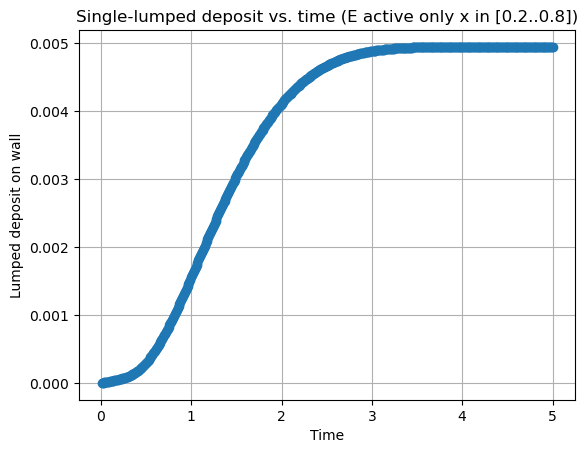

Plot done. You can switch time-steps in the GUI.


In [158]:
import netgen.meshing as meshing
from netgen.geom2d import SplineGeometry
from ngsolve import *
from ngsolve.solvers import GMRes
from ngsolve.la import BaseMatrix
from ngsolve.webgui import Draw

import numpy as np
import matplotlib.pyplot as plt

class IdentityPreconditioner(BaseMatrix):
    """
    Minimal 'Identity' preconditioner so GMRes can do: pre*x => x.
    """
    def __init__(self, size):
        super().__init__()
        self._size = size
    def Height(self): return self._size
    def Width(self):  return self._size
    def Mult(self, x, y):
        # y = x
        y.data = x


def SolveKineticDeposition_WithRemoval(
    mesh,
    velocity_cf,
    E_cf,
    D=1e-3,
    mu_e=1e-1,
    dt=0.01,
    T=2.0,
    c0_value=0.5,
    inflow_c=1.0,
    kd=1.0
):
    """
    Solve the PDE:
        ∂c/∂t + ∇·((u + mu_e·E) c) = D·Δc   in Ω,
    with a boundary removal flux:  -k_d·c  on "wall" (top/bottom boundary).
    
    We track a single “lumped deposit” by integrating c along "wall" at each step
    and subtracting from c with the flux.  The final 'deposit' is stored in deposit_history.
    The solution c at each time step is stored in c_timeline.
    """
    fes_c = H1(mesh, order=1, dirichlet="inflow")
    c_gf = GridFunction(fes_c, "c")
    
    # Set initial c in the domain
    c_gf.Set(c0_value)
    # Overwrite inflow boundary x=0 with c=inflow_c
    c_gf.Set(inflow_c, definedon=mesh.Boundaries("inflow"))

    lumps_deposit = 0.0

    u = fes_c.TrialFunction()
    v = fes_c.TestFunction()

    # Mass matrix
    mass = BilinearForm(fes_c, symmetric=True)
    mass += u*v*dx
    mass.Assemble()

    # Combine velocity + scaled E
    drift_cf = velocity_cf + mu_e * E_cf

    # PDE bilinear form
    a = BilinearForm(fes_c, symmetric=False)
    # diffusion
    a += D * InnerProduct(grad(u), grad(v)) * dx
    # advection + drift
    a += (drift_cf * grad(u)) * v * dx
    # boundary flux => + k_d·u·v on "wall", for removal flux (the PDE side sees +k_d)
    a += kd * u * v * ds("wall")

    a.Assemble()

    mat = mass.mat.CreateMatrix()
    mat.AsVector().data = mass.mat.AsVector() + dt*a.mat.AsVector()

    # We'll do an identity preconditioner + GMRes; or a direct solver if you prefer
    pre = IdentityPreconditioner(mat.height)

    old_sol = c_gf.vec.CreateVector()
    old_sol.data = c_gf.vec
    rhs_vec = c_gf.vec.CreateVector()

    # We'll store the solution in a multi-dim GF for post-processing
    c_timeline = GridFunction(fes_c, multidim=0)
    c_timeline.AddMultiDimComponent(c_gf.vec)

    times = []
    deposit_history = []

    nsteps = int(T / dt)

    for step in range(nsteps):
        tcur = (step+1)*dt

        # implicit Euler: (M + dt*A)*c^(n+1) = M*c^n
        rhs_vec.data = mass.mat * old_sol
        c_gf.vec.data = 0.0 * c_gf.vec

        # Solve with GMRes
        GMRes(
            A=mat,
            b=rhs_vec,
            x=c_gf.vec,
            pre=pre,
            maxsteps=1000,
            tol=1e-8,
            restart=1000,
            printrates=False
        )
        if step % 100 == 0:
            c_timeline.AddMultiDimComponent(c_gf.vec)
        old_sol.data = c_gf.vec

        # measure average c on the "wall", assume top boundary length ~ 1
        c_int = Integrate(c_gf, mesh, BND, definedon=mesh.Boundaries("wall"))
        c_wall = c_int  # if total length is 1

        lumps_deposit += dt * kd * (c_wall)
        times.append(tcur)
        deposit_history.append(lumps_deposit)

        print(f"Step {step+1}/{nsteps}, time={tcur:.2f}, c_wall={c_wall:.4e}, deposit={lumps_deposit:.4e}")

    return c_timeline, times, deposit_history


if __name__=="__main__":
    # 1) Build a simple rectangle geometry: [0,1] x [0,0.1]
    geo = SplineGeometry()
    geo.AddRectangle((0,0),(1,0.1), bcs=["inflow","wall","outflow","wall"])
    mesh = Mesh(geo.GenerateMesh(maxh=0.002))   # optional: finer mesh because of smaller domain

    # 2) Define velocity in x and a piecewise E in y that is active only for x in [0.2, 0.8]
    from ngsolve import x, y, IfPos

    # velocity is parabolic in y-direction (0 to 0.1)
    velocity_cf = CoefficientFunction((4*(y/0.1)*(1-(y/0.1)), 0))

    # E_switch = 1 if 0.2 <= x <= 0.8, else 0
    E_switch = IfPos(x-0.2, IfPos(0.8-x, 1.0, 0.0), 0.0)
    E_cf = CoefficientFunction((0, E_switch))

    # 3) Solve PDE with boundary removal
    c_hist, times, deposit_hist = SolveKineticDeposition_WithRemoval(
        mesh=mesh,
        velocity_cf=velocity_cf,
        E_cf=E_cf,
        D=1e-3,
        mu_e=1e-1,
        dt=0.01,
        T=5.0,
        c0_value=0.5,
        inflow_c=1.0,
        kd=2.0
    )
    print("Solver finished. Final lumps deposit=", deposit_hist[-1])

    # 4) Plot lumps deposit vs time
    plt.figure()
    plt.plot(times, deposit_hist, marker='o', linestyle='--')
    plt.xlabel("Time")
    plt.ylabel("Lumped deposit on wall")
    plt.title("Single-lumped deposit vs. time (E active only x in [0.2..0.8])")
    plt.grid(True)
    plt.savefig("scurve.png")
    plt.show()

    # 5) Visualize the solution in NGSolve
    Draw(c_hist, mesh, "c_timeline")
    print("Plot done. You can switch time-steps in the GUI.")

# Decomposition profile

Tracing particles:   0%|          | 0/1000 [00:00<?, ?step/s]/var/folders/mk/4mjy11c91yj95qwrm69075100000gq/T/ipykernel_5103/811483278.py:57: RuntimeWarning: divide by zero encountered in divide
  fraction = np.where(crossing, (1.0 - ya) / (ya_new - ya), 0.0)
Tracing particles: 100%|██████████| 1000/1000 [03:03<00:00,  5.46step/s]


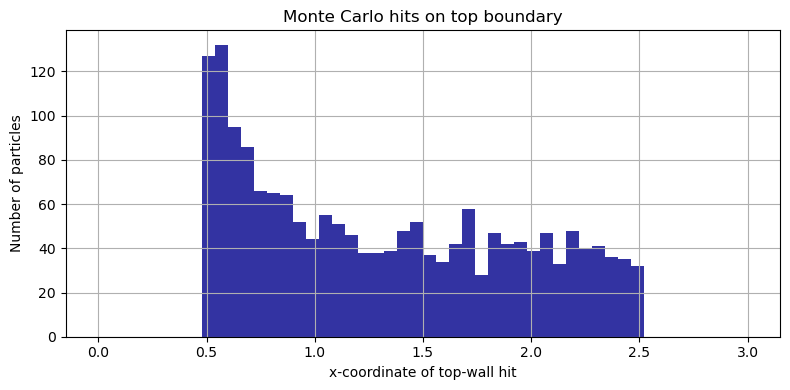

✅ Monte Carlo complete.
Particles hitting top wall: 1780


In [154]:
import numpy as np
import matplotlib.pyplot as plt
from ngsolve import Mesh, CoefficientFunction, IfPos
from tqdm import tqdm  # ✅ Added progress bar

def MonteCarloHitDistribution(
    mesh,
    velocity_cf,
    E_cf,
    mu_e=0.2,
    nparticles=3000,
    dt=0.005,
    max_time=5.0,
    show_plot=True
):
    y0 = np.random.rand(nparticles)
    x0 = np.zeros(nparticles)

    xs = x0.copy()
    ys = y0.copy()
    hits_x = np.full(nparticles, np.nan)

    nsteps = int(max_time / dt)

    for step in tqdm(range(nsteps), desc="Tracing particles", unit="step"):
        active = np.isnan(hits_x)
        if not np.any(active):
            break

        xa = xs[active]
        ya = ys[active]

        inside = (xa >= 0) & (xa <= 3) & (ya >= 0) & (ya <= 1)
        xa = xa[inside]
        ya = ya[inside]
        active_idx = np.where(active)[0][inside]

        if len(xa) == 0:
            break

        vx_vals = np.empty_like(xa)
        vy_vals = np.empty_like(xa)
        Ex_vals = np.empty_like(xa)
        Ey_vals = np.empty_like(xa)

        for i in range(len(xa)):
            vx_vals[i], vy_vals[i] = velocity_cf(mesh(xa[i], ya[i]))
            Ex_vals[i], Ey_vals[i] = E_cf(mesh(xa[i], ya[i]))

        vx_vals += mu_e * Ex_vals
        vy_vals += mu_e * Ey_vals

        xa_new = xa + dt * vx_vals
        ya_new = ya + dt * vy_vals

        crossing = (ya < 1.0) & (ya_new >= 1.0)
        fraction = np.where(crossing, (1.0 - ya) / (ya_new - ya), 0.0)
        x_hit = xa + fraction * (xa_new - xa)

        idx_cross = active_idx[crossing]
        hits_x[idx_cross] = x_hit[crossing]

        xa = xa_new
        ya = ya_new
        xs[active_idx] = xa
        ys[active_idx] = ya

    if show_plot:
        valid_hits = hits_x[~np.isnan(hits_x)]
        plt.figure(figsize=(8, 4))
        plt.hist(valid_hits, bins=50, range=(0, 3.0), color='darkblue', alpha=0.8)
        plt.xlabel("x-coordinate of top-wall hit")
        plt.ylabel("Number of particles")
        plt.title("Monte Carlo hits on top boundary")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("MonteCarloHits_E=0,4-U=7,0.png")
        plt.show()

    return hits_x

# ------------- RUN THE SIMULATION -------------
if __name__ == "__main__":
    from netgen.geom2d import SplineGeometry
    from ngsolve import x, y

    geo = SplineGeometry()
    geo.AddRectangle((0, 0), (3, 1), bcs=["inflow", "wall", "outflow", "wall"])
    mesh = Mesh(geo.GenerateMesh(maxh=0.005))

    velocity_cf = CoefficientFunction((7 * y * (1 - y), 0))
    E_switch = IfPos(x - 0.5, IfPos(2.5 - x, 1.0, 0.0), 0.0)
    E_cf = CoefficientFunction((0, E_switch))

    hits = MonteCarloHitDistribution(
        mesh=mesh,
        velocity_cf=velocity_cf,
        E_cf=E_cf,
        mu_e=0.4,
        nparticles=3000,
        dt=0.005,
        max_time=5.0,
        show_plot=True
    )

    print("✅ Monte Carlo complete.")
    print("Particles hitting top wall:", np.count_nonzero(~np.isnan(hits)))

# Consentration Gradient Analysis

In [156]:
import netgen.meshing as meshing
from netgen.geom2d import SplineGeometry
from ngsolve import *
from ngsolve.solvers import GMRes
from ngsolve.la import BaseMatrix
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # ✅ for progress bar


class IdentityPreconditioner(BaseMatrix):
    def __init__(self, size):
        super().__init__()
        self._size = size
    def Height(self): return self._size
    def Width(self): return self._size
    def Mult(self, x, y): y.data = x


def SolveKineticDeposition_WithMassTracking(
    mesh,
    velocity_cf,
    E_cf,
    D=1e-3,
    mu_e=1e-1,
    dt=0.01,
    T=2.0,
    c0_value=3.0,
    kd=1.0
):
    fes_c = H1(mesh, order=1)
    c_gf = GridFunction(fes_c, "c")
    c_gf.Set(c0_value)

    u = fes_c.TrialFunction()
    v = fes_c.TestFunction()

    mass = BilinearForm(fes_c, symmetric=True)
    mass += u*v*dx
    mass.Assemble()

    drift_cf = velocity_cf + mu_e * E_cf

    a = BilinearForm(fes_c, symmetric=False)
    a += D * InnerProduct(grad(u), grad(v)) * dx
    a += (drift_cf * grad(u)) * v * dx
    a += kd * u * v * ds("wall")
    a.Assemble()

    mat = mass.mat.CreateMatrix()
    mat.AsVector().data = mass.mat.AsVector() + dt * a.mat.AsVector()

    pre = IdentityPreconditioner(mat.height)
    old_sol = c_gf.vec.CreateVector()
    old_sol.data = c_gf.vec
    rhs_vec = c_gf.vec.CreateVector()

    c_snapshots = [c_gf.vec.CreateVector()]
    c_snapshots[0].data = c_gf.vec

    times, deposit_history, mass_history = [], [], []
    lumps_deposit = 0.0

    nsteps = int(T / dt)

    # ✅ Add progress bar
    for step in tqdm(range(nsteps), desc="Simulating", unit="step"):
        tcur = (step + 1) * dt
        rhs_vec.data = mass.mat * old_sol
        c_gf.vec.data = 0.0 * c_gf.vec

        GMRes(A=mat, b=rhs_vec, x=c_gf.vec, pre=pre, maxsteps=1000,
              tol=1e-8, restart=1000, printrates=False)

        old_sol.data = c_gf.vec

        c_snapshots.append(c_gf.vec.CreateVector())
        c_snapshots[-1].data = c_gf.vec

        c_wall = Integrate(c_gf, mesh, BND, definedon=mesh.Boundaries("wall"))
        lumps_deposit += dt * kd * c_wall

        total_mass = Integrate(c_gf, mesh)
        times.append(tcur)
        deposit_history.append(lumps_deposit)
        mass_history.append(total_mass)

    return c_snapshots, fes_c, times, mass_history


def polygon_area(vertices):
    x = [p[0] for p in vertices]
    y = [p[1] for p in vertices]
    return 0.5 * abs(sum(x[i]*y[(i+1)%len(vertices)] - x[(i+1)%len(vertices)]*y[i] for i in range(len(vertices))))


def compute_mass_profile_upper_half(gf, mesh, nx=100, y_min=0.5):
    x_bins = np.linspace(0, 3, nx+1)
    bin_totals = np.zeros(nx)
    bin_areas = np.zeros(nx)

    el_conc = Integrate(gf, mesh, element_wise=True)

    for el in mesh.Elements(VOL):
        vertex_coords = [mesh[vnr].point for vnr in el.vertices]
        y_coords = [p[1] for p in vertex_coords]

        if all(y >= y_min for y in y_coords):
            x_center = sum(p[0] for p in vertex_coords) / len(vertex_coords)
            bin_index = np.searchsorted(x_bins, x_center) - 1
            if 0 <= bin_index < nx:
                area = polygon_area(vertex_coords)
                bin_totals[bin_index] += el_conc[el.nr]
                bin_areas[bin_index] += area

    x_centers = 0.5 * (x_bins[:-1] + x_bins[1:])
    avg_concentration = np.divide(bin_totals, bin_areas, out=np.zeros_like(bin_totals), where=bin_areas > 0)
    return x_centers, avg_concentration


if __name__ == "__main__":
    geo = SplineGeometry()
    geo.AddRectangle((0, 0), (3, 1), bcs=["inflow", "outflow", "outflow", "wall"])
    mesh = Mesh(geo.GenerateMesh(maxh=0.02))

    from ngsolve import x, y, IfPos
    velocity_cf = CoefficientFunction((5 * y * (1 - y), 0))
    E_switch = IfPos(x - 0.5, IfPos(2.5 - x, 1.0, 0.0), 0.0)
    E_strength = 2
    E_cf = CoefficientFunction((0, E_strength * E_switch))

    mu_e = 0.2
    kd = 1.0
    T = 10.0
    D = 0.001 

    c_snapshots, fes_c, times, mass_history = SolveKineticDeposition_WithMassTracking(
        mesh=mesh,
        velocity_cf=velocity_cf,
        E_cf=E_cf,
        D=D,
        mu_e=mu_e,
        dt=0.01,
        T=T,
        c0_value=3.0,
        kd=kd
    )

    print("✅ Simulation finished.")

Simulating: 100%|██████████| 1000/1000 [00:58<00:00, 17.19step/s]


✅ Simulation finished.


/var/folders/mk/4mjy11c91yj95qwrm69075100000gq/T/ipykernel_5103/2649106223.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


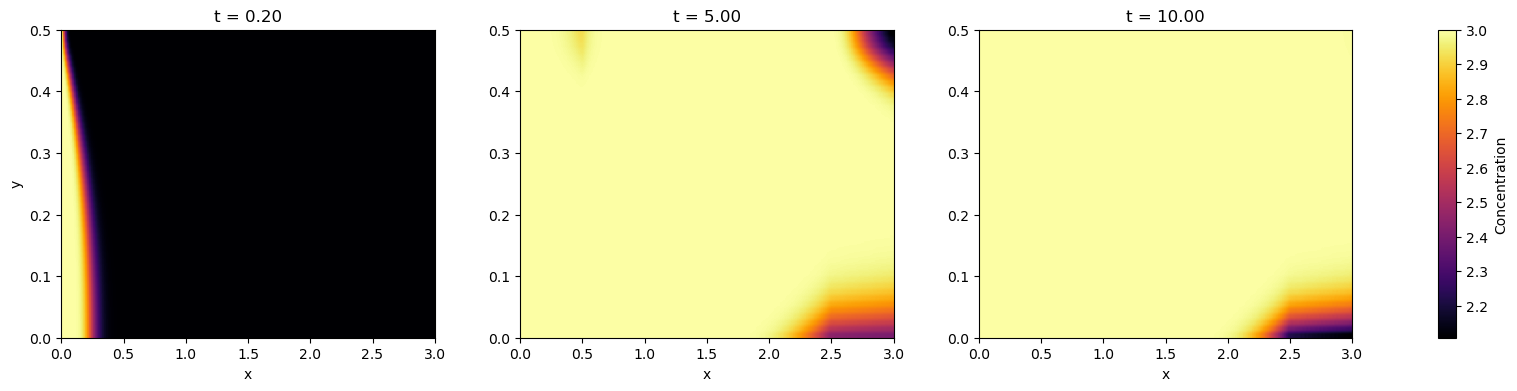

In [157]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ✅ Select snapshot indices
snapshot_indices = [20, len(c_snapshots)//2, len(c_snapshots)-1]
snapshot_labels = [f"t = {times[i-1]:.2f}" for i in snapshot_indices]

# ✅ Grid for upper half of the domain
Nx = 200
Ny_half = 50
x_vals = np.linspace(0, 3.0, Nx)
y_vals_half = np.linspace(0.5, 1.0, Ny_half)
X_half, Y_half = np.meshgrid(x_vals, y_vals_half)
points_half = list(zip(X_half.ravel(), Y_half.ravel()))

# ✅ Create figure with gridspec
fig = plt.figure(figsize=(18, 4))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.3)
axs = [fig.add_subplot(gs[i]) for i in range(3)]
cax = fig.add_subplot(gs[3])  # colorbar axis

max_c0 = 3.0  # initial concentration

for ax, idx, label in zip(axs, snapshot_indices, snapshot_labels):
    tmp_gf = GridFunction(fes_c)
    tmp_gf.vec.data = c_snapshots[idx]

    c_vals_half = np.array([tmp_gf(x, y) for (x, y) in points_half]).reshape(Y_half.shape)
    corrected_vals = max_c0 - c_vals_half

    im = ax.imshow(corrected_vals, origin='lower', extent=(0, 3.0, 0.0, 0.5),
                   cmap='inferno', aspect='auto')
    ax.set_title(label)
    ax.set_xlabel("x")
    if ax == axs[0]:
        ax.set_ylabel("y")

# ✅ Add colorbar to the right-most axis
fig.colorbar(im, cax=cax, label='Concentration')

plt.tight_layout()
plt.savefig("E=0,2-kd=1,0-T=10,0-D=0,001-U=5.png")
plt.show()

# Convergence 


🔁 Running for maxh = 0.2


⏳ Solving PDE: 100%|██████████| 100/100 [00:21<00:00,  4.55step/s]



🔁 Running for maxh = 0.1


⏳ Solving PDE: 100%|██████████| 100/100 [00:27<00:00,  3.63step/s]



🔁 Running for maxh = 0.05


⏳ Solving PDE: 100%|██████████| 100/100 [00:42<00:00,  2.34step/s]



🔁 Running for maxh = 0.025


⏳ Solving PDE: 100%|██████████| 100/100 [01:37<00:00,  1.02step/s]



📈 Experimental Order of Convergence:
h = 0.2000 → 0.1000 | L2 EOC: -1.78, Linf EOC: -2.17
h = 0.1000 → 0.0500 | L2 EOC: 2.70, Linf EOC: 3.74
h = 0.0500 → 0.0250 | L2 EOC: 0.28, Linf EOC: 0.56


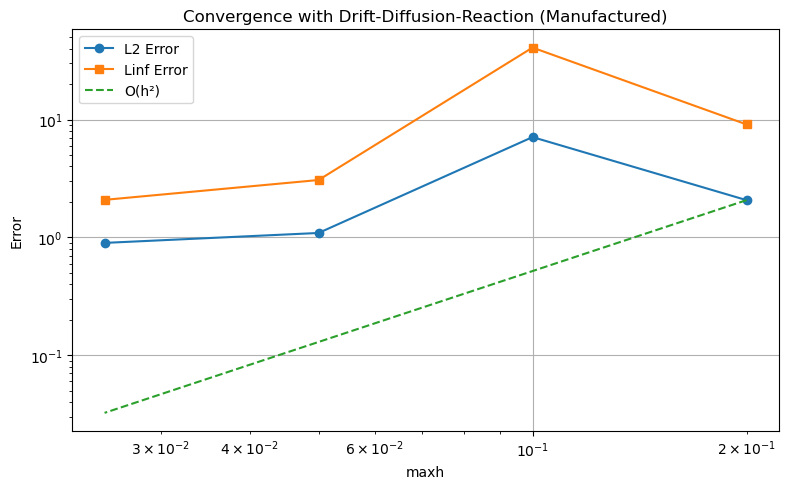

In [95]:
from ngsolve import *
from netgen.geom2d import SplineGeometry
import numpy as np
import matplotlib.pyplot as plt
from ngsolve.solvers import GMRes
from ngsolve.la import BaseMatrix
from tqdm import tqdm  # ✅ Progress bar

class IdentityPreconditioner(BaseMatrix):
    def __init__(self, size):
        super().__init__()
        self._size = size
    def Height(self): return self._size
    def Width(self): return self._size
    def Mult(self, x, y): y.data = x

def manufactured_solution_convergence(mesh, t_end=1.0, dt=0.01, D=1e-3, mu_e=0.5, kd=1):
    fes = H1(mesh, order=2, dirichlet="left|right|top|bottom")
    c = GridFunction(fes, "c")
    u, v = fes.TnT()

    from ngsolve import x, y, pi, sin, cos, exp
    def c_exact_time(t): return sin(pi*x) * sin(pi*y) * exp(-t)

    # Initial condition
    c.Set(c_exact_time(0))

    # Define drift terms
    velocity_cf = CoefficientFunction((4*y*(1-y), 0))
    E_switch = IfPos(x - 0.5, IfPos(2.5 - x, 1.0, 0.0), 0.0)
    E_cf = CoefficientFunction((0, E_switch))
    drift_cf = velocity_cf + mu_e * E_cf

    # Mass and stiffness matrices
    mass = BilinearForm(fes)
    mass += u * v * dx
    mass.Assemble()

    a = BilinearForm(fes)
    a += D * grad(u) * grad(v) * dx
    a += (drift_cf * grad(u)) * v * dx
    a += kd * u * v * ds("wall")  # Reaction on boundary
    a.Assemble()

    mat = mass.mat + dt * a.mat
    rhs = c.vec.CreateVector()
    pre = IdentityPreconditioner(mat.height)

    times = np.arange(0, t_end + dt, dt)

    # ✅ Add progress bar here
    for t in tqdm(times[1:], desc="⏳ Solving PDE", unit="step"):
        # Source term f = ∂c/∂t - DΔc + div(v c + mu_e E c)
        c_ex = sin(pi*x) * sin(pi*y) * exp(-t)
        grad_c = CoefficientFunction((pi*cos(pi*x)*sin(pi*y), pi*sin(pi*x)*cos(pi*y))) * exp(-t)
        div_term = grad_c * drift_cf
        laplace_term = -D * 2 * pi**2 * c_ex
        time_term = -c_ex
        f_rhs = time_term + laplace_term + div_term

        lf = LinearForm(fes)
        lf += f_rhs * v * dx
        lf.Assemble()

        rhs.data = mass.mat * c.vec + dt * lf.vec
        c.vec.data = 0 * c.vec

        GMRes(A=mat, b=rhs, x=c.vec, pre=pre, maxsteps=1000, tol=1e-8, restart=50, printrates=False)

    # Compute L2 error
    c_exact_t = c_exact_time(t_end)
    l2_error = sqrt(Integrate((c - c_exact_t)**2, mesh))

    # Compute Linf error using max nodal value difference
    tmp_gf = GridFunction(fes)
    tmp_gf.Set(c_exact_t)

    linf_error = 0
    for el in mesh.Elements(VOL):
        for v in el.vertices:
            p = mesh[v].point
            val = abs(c(p[0], p[1]) - tmp_gf(p[0], p[1]))
            linf_error = max(linf_error, val)

    return l2_error, linf_error

def compute_eoc(errors, hs):
    return [np.log(errors[i-1]/errors[i]) / np.log(hs[i-1]/hs[i]) for i in range(1, len(errors))]

# Run convergence study
hs = [0.2, 0.1, 0.05, 0.025]
errors_l2, errors_linf = [], []

for h in hs:
    print(f"\n🔁 Running for maxh = {h}")
    geo = SplineGeometry()
    geo.AddRectangle((0, 0), (3, 1), bcs=["left", "right", "top", "bottom", "wall"])
    mesh = Mesh(geo.GenerateMesh(maxh=h))
    l2, linf = manufactured_solution_convergence(mesh)
    errors_l2.append(l2)
    errors_linf.append(linf)

# EOC
eoc_l2 = compute_eoc(errors_l2, hs)
eoc_linf = compute_eoc(errors_linf, hs)

print("\n📈 Experimental Order of Convergence:")
for i in range(1, len(hs)):
    print(f"h = {hs[i-1]:.4f} → {hs[i]:.4f} | L2 EOC: {eoc_l2[i-1]:.2f}, Linf EOC: {eoc_linf[i-1]:.2f}")

# Plot convergence
plt.figure(figsize=(8, 5))
plt.loglog(hs, errors_l2, '-o', label="L2 Error")
plt.loglog(hs, errors_linf, '-s', label="Linf Error")
plt.loglog(hs, [errors_l2[0]*(h/hs[0])**2 for h in hs], '--', label="O(h²)")
plt.xlabel("maxh")
plt.ylabel("Error")
plt.grid(True)
plt.legend()
plt.title("Convergence with Drift-Diffusion-Reaction (Manufactured)")
plt.tight_layout()
plt.savefig("convergence_drift_diffusion_reaction.png")
plt.show()